# Capítulo 6, Sección 6.3 — Ejemplo 3: Inversión de parámetros con PINNs

Este cuaderno replica computacionalmente el **Ejemplo 3** de la Sección 6.3: un problema inverso para una ecuación de difusión donde el parámetro físico desconocido es el coeficiente de difusión $\kappa$.

El libro plantea la ecuación

$
\frac{\partial u}{\partial t}-\kappa\frac{\partial^2u}{\partial x^2}=0,
\qquad x\in[0,L],\quad t\in[0,T],$

con condición inicial

$
u(x,0)=h(x),$

condiciones de frontera

$
u(0,t)=g_1(t),\qquad u(L,t)=g_2(t),
$

y datos observados dispersos

$
u(x_d^i,t_d^i)=u_d^i.
$

El objetivo no es solo aproximar el campo $u(x,t)$, sino también recuperar el parámetro desconocido $\kappa$. La PINN hace ambas cosas en una sola optimización.

## Nota honesta, para que no nos metamos otra vez en una novela innecesaria

El libro **no fija** explícitamente valores concretos de $L,T,h,g_1,g_2$ ni de $\kappa$. Para que el notebook sea ejecutable y verificable, usamos un caso manufacturado:

$
L=1,\qquad T=1,
$

$
h(x)=\sin(\pi x),
\qquad g_1(t)=g_2(t)=0,
$

con solución exacta

$
u_\star(x,t)=e^{-\kappa_\star\pi^2t}\sin(\pi x).
$

Esta elección permite generar pocos datos observados y luego comprobar si la PINN recupera $\kappa_\star$. La idea central sí es la del libro: **inversión conjunta de campo y parámetro mediante una pérdida física más una pérdida de datos**.

## 1. Importaciones y configuración

Usamos PyTorch porque necesitamos diferenciación automática respecto a las coordenadas $(x,t)$ y respecto al parámetro físico entrenable $\kappa$.

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as Fnn

np.random.seed(11)
torch.manual_seed(11)

# En Colab: Runtime/Entorno de ejecución -> Change runtime type -> GPU
# En español: Entorno de ejecución -> Cambiar tipo de entorno de ejecución -> GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__)
print('Dispositivo:', device)

PyTorch: 2.11.0+cpu
Dispositivo: cpu


## 2. Problema manufacturado para validar la inversión

La solución exacta elegida es

$
u_\star(x,t)=e^{-\kappa_\star\pi^2t}\sin(\pi x).
$

Verificación rápida:

$
u_t=-\kappa_\star\pi^2e^{-\kappa_\star\pi^2t}\sin(\pi x),
$

$
u_{xx}=-\pi^2e^{-\kappa_\star\pi^2t}\sin(\pi x),
$

entonces

$
u_t-\kappa_\star u_{xx}=0.
$

Así podemos saber si la red recuperó bien el parámetro. Sí, aquí sí sabemos la respuesta, porque uno no calibra un método nuevo manejando a ciegas como si fuera iluminado.

In [ ]:
# Dominio espacio-temporal
L = 1.0
T_FINAL = 1.0

# Parámetro real que vamos a esconderle a la PINN
KAPPA_TRUE = 0.20

# Valor inicial desde el cual la red intentará descubrir kappa
KAPPA_INIT = 0.1

pi = np.pi


def u_exact_np(x, t, kappa=KAPPA_TRUE):
    '''Solución exacta para el caso manufacturado.'''
    return np.exp(-kappa * pi**2 * t) * np.sin(pi * x)


def h_initial_np(x):
    '''Condición inicial h(x).'''
    return np.sin(pi * x)


def g_left_np(t):
    '''Frontera izquierda u(0,t).'''
    return np.zeros_like(t)


def g_right_np(t):
    '''Frontera derecha u(1,t).'''
    return np.zeros_like(t)


def to_col(a, requires_grad=False):
    '''Convierte arreglos de NumPy en tensores columna de PyTorch.'''
    t = torch.tensor(a, dtype=torch.float32, device=device).reshape(-1, 1)
    return t.requires_grad_(requires_grad)

## 3. Visualización de la solución exacta

Antes de entrenar, miramos qué campo queremos reconstruir. El eje horizontal es $x$ y el vertical es $t$.

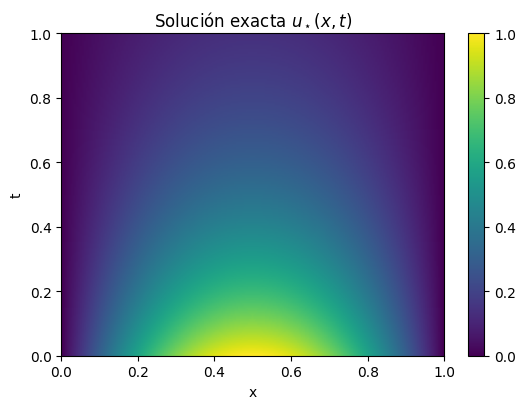

In [ ]:
n_plot = 201
xv = np.linspace(0, L, n_plot)
tv = np.linspace(0, T_FINAL, n_plot)
X, TT = np.meshgrid(xv, tv, indexing='xy')
U_star = u_exact_np(X, TT)

fig, ax = plt.subplots(figsize=(5.6, 4.2))
im = ax.imshow(U_star, origin='lower', extent=[0, L, 0, T_FINAL], aspect='auto', cmap='viridis')
ax.set_title(r'Solución exacta $u_\star(x,t)$')
ax.set_xlabel('x')
ax.set_ylabel('t')
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 4. Muestreo sin malla: puntos de física, frontera, condición inicial y datos

La pérdida del libro para el problema inverso tiene cuatro partes:

$
\mathcal L(\theta,\kappa)
=
\lambda_f\mathcal L_f
+
\lambda_i\mathcal L_i
+
\lambda_b\mathcal L_b
+
\lambda_d\mathcal L_d.
$

Aquí usamos cuatro grupos de puntos:

- puntos interiores $(x_f,t_f)$, donde se evalúa el residuo de la EDP;
- puntos de condición inicial $(x_i,0)$;
- puntos de frontera $(0,t_b)$ y $(1,t_b)$;
- pocos datos observados $(x_d,t_d,u_d)$, que son los que permiten identificar $\kappa$.

In [ ]:
# Tamaños de muestra
N_F = 3000       # puntos de residuo físico
N_I = 250        # puntos de condición inicial
N_B = 250        # puntos por lado de frontera
N_D = 20         # datos observados dispersos, como en el ejemplo del libro

# Ruido relativo en los datos observados. Pon 0.01 para 1% de ruido aproximado.
NOISE_REL = 0.00

# Puntos interiores para la EDP
x_f_np = np.random.rand(N_F) * L
t_f_np = np.random.rand(N_F) * T_FINAL

# Puntos para condición inicial t=0
x_i_np = np.random.rand(N_I) * L
t_i_np = np.zeros(N_I)
u_i_np = h_initial_np(x_i_np)

# Puntos de frontera x=0 y x=L
s_b = np.random.rand(N_B) * T_FINAL
x_b_np = np.concatenate([np.zeros(N_B), L*np.ones(N_B)])
t_b_np = np.concatenate([s_b, s_b])
u_b_np = np.concatenate([g_left_np(s_b), g_right_np(s_b)])

# Datos observados en el interior espacio-temporal
# Evitamos t demasiado cercano a 0 para que los datos sí informen sobre kappa.
x_d_np = np.random.rand(N_D) * L
t_d_np = 0.05 + 0.95*np.random.rand(N_D) * T_FINAL
u_d_clean_np = u_exact_np(x_d_np, t_d_np)

noise_scale = NOISE_REL * np.std(u_d_clean_np)
u_d_np = u_d_clean_np + noise_scale*np.random.randn(N_D)

# Convertimos a tensores. En los puntos de física necesitamos requires_grad=True.
x_f = to_col(x_f_np, requires_grad=True)
t_f = to_col(t_f_np, requires_grad=True)

x_i = to_col(x_i_np)
t_i = to_col(t_i_np)
u_i = to_col(u_i_np)

x_b = to_col(x_b_np)
t_b = to_col(t_b_np)
u_b = to_col(u_b_np)

x_d = to_col(x_d_np)
t_d = to_col(t_d_np)
u_d = to_col(u_d_np)

print('Puntos de física:', x_f.shape[0])
print('Puntos de condición inicial:', x_i.shape[0])
print('Puntos de frontera:', x_b.shape[0])
print('Datos observados:', x_d.shape[0])

Puntos de física: 3000
Puntos de condición inicial: 250
Puntos de frontera: 500
Datos observados: 20


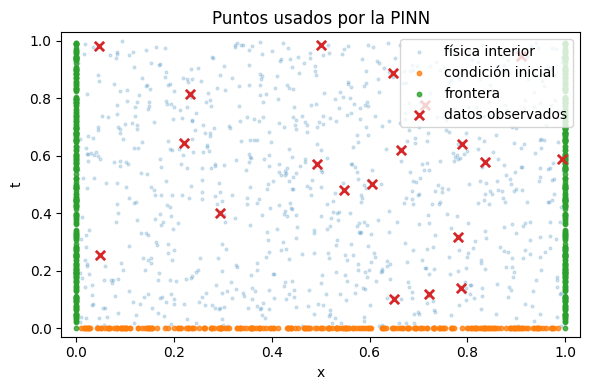

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x_f_np[:900], t_f_np[:900], s=4, alpha=0.18, label='física interior')
ax.scatter(x_i_np, t_i_np, s=10, alpha=0.8, label='condición inicial')
ax.scatter(x_b_np, t_b_np, s=10, alpha=0.8, label='frontera')
ax.scatter(x_d_np, t_d_np, s=45, marker='x', linewidths=2, label='datos observados')
ax.set_xlim(-0.03, L+0.03)
ax.set_ylim(-0.03, T_FINAL+0.03)
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title('Puntos usados por la PINN')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 5. Red neuronal y parámetro entrenable

La red $\widehat u(x,t;\theta)$ aproxima el campo completo.

El parámetro físico $\kappa$ se aprende como un escalar entrenable. Para garantizar que sea positivo, no entrenamos directamente $\kappa$, sino un parámetro libre `raw_kappa` y luego usamos

$
\kappa=\operatorname{softplus}(\texttt{raw\_kappa}).
$

Así evitamos que el optimizador proponga una difusión negativa, porque eso sería una genialidad bastante inútil.

In [ ]:
def softplus_inverse(y):
    '''Inversa numérica de softplus para inicializar raw_kappa.'''
    y = np.asarray(y)
    return np.log(np.expm1(y))


class InverseDiffusionPINN(nn.Module):
    def __init__(self, width=64, depth=4, kappa_init=KAPPA_INIT):
        super().__init__()
        layers = []
        dims = [2] + [width]*depth + [1]
        for j in range(len(dims)-1):
            layers.append(nn.Linear(dims[j], dims[j+1]))
            if j < len(dims)-2:
                layers.append(nn.Tanh())
        self.net = nn.Sequential(*layers)

        # Inicialización Xavier, razonable para MLP con tanh.
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

        raw0 = float(softplus_inverse(kappa_init))
        self.raw_kappa = nn.Parameter(torch.tensor(raw0, dtype=torch.float32))

    @property
    def kappa(self):
        return Fnn.softplus(self.raw_kappa) + 1e-8

    def forward(self, x, t):
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)


model = InverseDiffusionPINN(width=64, depth=4).to(device)
print(model)
print('kappa inicial:', float(model.kappa.detach().cpu()))
print('kappa real:', KAPPA_TRUE)

InverseDiffusionPINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)
kappa inicial: 0.10000000894069672
kappa real: 0.2


## 6. Derivadas automáticas y residuo físico

El residuo físico es

$
r_\theta(x,t)=\frac{\partial \widehat u}{\partial t}(x,t)-\kappa\frac{\partial^2\widehat u}{\partial x^2}(x,t).
$

Si la red satisface la ecuación de difusión, entonces este residuo debe ser cercano a cero.

In [ ]:
def grad(outputs, inputs):
    '''Derivada automática d(outputs)/d(inputs).'''
    return torch.autograd.grad(
        outputs,
        inputs,
        grad_outputs=torch.ones_like(outputs),
        create_graph=True,
        retain_graph=True,
    )[0]


def diffusion_residual(model, x, t):
    '''r = u_t - kappa*u_xx.'''
    u = model(x, t)
    u_t = grad(u, t)
    u_x = grad(u, x)
    u_xx = grad(u_x, x)
    return u_t - model.kappa * u_xx

## 7. Función de pérdida

La pérdida total implementa exactamente la estructura conceptual del ejemplo:

$
\mathcal L(\theta,\kappa)
=
\lambda_f\mathcal L_f
+
\lambda_i\mathcal L_i
+
\lambda_b\mathcal L_b
+
\lambda_d\mathcal L_d.
$

Concretamente:

$
\mathcal L_f = \frac1{N_f}\sum_i |r_\theta(x_f^i,t_f^i)|^2,
$

$
\mathcal L_i = \frac1{N_i}\sum_i |\widehat u(x_i,0)-h(x_i)|^2,
$

$
\mathcal L_b = \frac1{N_b}\sum_i |\widehat u(x_b,t_b)-g(t_b)|^2,
$

$
\mathcal L_d = \frac1{N_d}\sum_i |\widehat u(x_d^i,t_d^i;\theta)-u_d^i|^2.
$

In [ ]:
# Pesos de la pérdida. La parte de datos se pondera fuerte porque N_D es pequeño.
LAMBDA_F = 1.0
LAMBDA_I = 10.0
LAMBDA_B = 10.0
LAMBDA_D = 100.0


def loss_terms(model):
    r = diffusion_residual(model, x_f, t_f)
    loss_f = torch.mean(r**2)
    loss_i = torch.mean((model(x_i, t_i) - u_i)**2)
    loss_b = torch.mean((model(x_b, t_b) - u_b)**2)
    loss_d = torch.mean((model(x_d, t_d) - u_d)**2)
    total = LAMBDA_F*loss_f + LAMBDA_I*loss_i + LAMBDA_B*loss_b + LAMBDA_D*loss_d
    return total, loss_f, loss_i, loss_b, loss_d

## 8. Entrenamiento conjunto de $\theta$ y $\kappa$

Actualizamos simultáneamente:

- los pesos de la red $\theta$, que representan el campo $\widehat u(x,t)$;
- el parámetro físico $\kappa$, que aparece dentro del residuo de la ecuación.

In [ ]:
# En GPU se puede entrenar más. En CPU dejamos menos pasos para que no sea una penitencia.
N_STEPS = 20000 if device.type == 'cuda' else 4500
PRINT_EVERY = max(500, N_STEPS // 8)

LR_NET = 1e-4
LR_KAPPA = 1e-4

optimizer = torch.optim.Adam([
    {'params': model.net.parameters(), 'lr': LR_NET},
    {'params': [model.raw_kappa], 'lr': LR_KAPPA},
])

hist = {
    'total': [],
    'pde': [],
    'ic': [],
    'bc': [],
    'data': [],
    'kappa': [],
}

start = time.time()
for it in range(N_STEPS + 1):
    optimizer.zero_grad(set_to_none=True)
    loss, loss_f, loss_i, loss_b, loss_d = loss_terms(model)
    loss.backward()
    optimizer.step()

    hist['total'].append(float(loss.detach().cpu()))
    hist['pde'].append(float(loss_f.detach().cpu()))
    hist['ic'].append(float(loss_i.detach().cpu()))
    hist['bc'].append(float(loss_b.detach().cpu()))
    hist['data'].append(float(loss_d.detach().cpu()))
    hist['kappa'].append(float(model.kappa.detach().cpu()))

    if it % PRINT_EVERY == 0:
        print(
            f"it={it:5d} | "
            f"total={hist['total'][-1]:.3e} | "
            f"Lf={hist['pde'][-1]:.3e} | "
            f"Li={hist['ic'][-1]:.3e} | "
            f"Lb={hist['bc'][-1]:.3e} | "
            f"Ld={hist['data'][-1]:.3e} | "
            f"kappa={hist['kappa'][-1]:.6f}"
        )

elapsed = time.time() - start
print(f"Tiempo de entrenamiento: {elapsed:.1f} s")
print(f"kappa real      = {KAPPA_TRUE:.6f}")
print(f"kappa estimado  = {float(model.kappa.detach().cpu()):.6f}")
print(f"error absoluto  = {abs(float(model.kappa.detach().cpu()) - KAPPA_TRUE):.6e}")

it=    0 | total=7.944e+00 | Lf=8.881e-02 | Li=2.394e-01 | Lb=8.801e-02 | Ld=4.581e-02 | kappa=0.100010
it=  562 | total=6.319e-01 | Lf=1.370e-01 | Li=2.018e-02 | Lb=1.419e-02 | Ld=1.512e-03 | kappa=0.107282
it= 1124 | total=1.061e-01 | Lf=7.496e-02 | Li=1.775e-03 | Lb=4.266e-04 | Ld=9.169e-05 | kappa=0.115985
it= 1686 | total=7.737e-02 | Lf=5.688e-02 | Li=1.271e-03 | Lb=2.262e-04 | Ld=5.520e-05 | kappa=0.123723
it= 2248 | total=6.116e-02 | Lf=4.475e-02 | Li=1.002e-03 | Lb=1.683e-04 | Ld=4.704e-05 | kappa=0.131146
it= 2810 | total=4.891e-02 | Lf=3.564e-02 | Li=8.130e-04 | Lb=1.391e-04 | Ld=3.745e-05 | kappa=0.138419
it= 3372 | total=3.934e-02 | Lf=2.856e-02 | Li=6.903e-04 | Lb=1.418e-04 | Ld=2.457e-05 | kappa=0.145614
it= 3934 | total=3.070e-02 | Lf=2.208e-02 | Li=5.270e-04 | Lb=1.027e-04 | Ld=2.328e-05 | kappa=0.152755
it= 4496 | total=2.368e-02 | Lf=1.686e-02 | Li=4.130e-04 | Lb=8.592e-05 | Ld=1.827e-05 | kappa=0.159828
Tiempo de entrenamiento: 328.2 s
kappa real      = 0.200000
kapp

## 9. Curvas de pérdida y evolución de $\kappa$

Si el entrenamiento está funcionando, la pérdida total debe bajar y el parámetro estimado debe acercarse a \(\kappa_\star\).

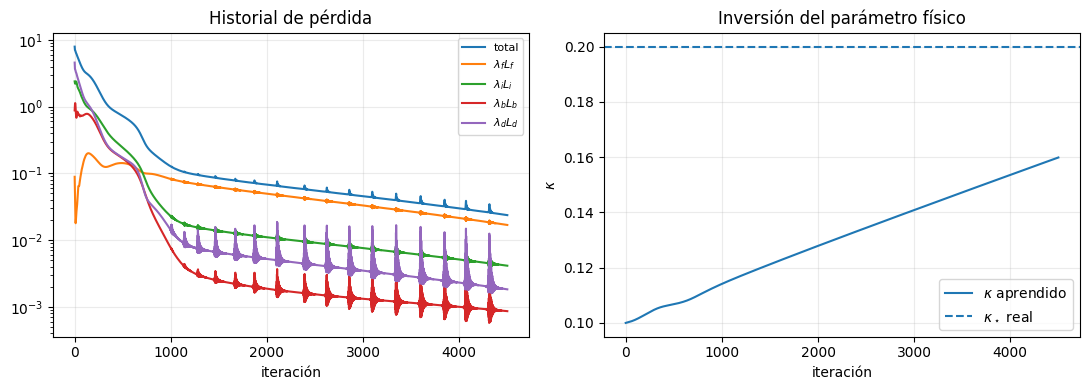

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4))

axs[0].semilogy(hist['total'], label='total')
axs[0].semilogy(np.array(hist['pde'])*LAMBDA_F, label=r'$\lambda_f L_f$')
axs[0].semilogy(np.array(hist['ic'])*LAMBDA_I, label=r'$\lambda_i L_i$')
axs[0].semilogy(np.array(hist['bc'])*LAMBDA_B, label=r'$\lambda_b L_b$')
axs[0].semilogy(np.array(hist['data'])*LAMBDA_D, label=r'$\lambda_d L_d$')
axs[0].set_title('Historial de pérdida')
axs[0].set_xlabel('iteración')
axs[0].grid(True, alpha=0.25)
axs[0].legend(fontsize=8)

axs[1].plot(hist['kappa'], label=r'$\kappa$ aprendido')
axs[1].axhline(KAPPA_TRUE, linestyle='--', label=r'$\kappa_\star$ real')
axs[1].set_title('Inversión del parámetro físico')
axs[1].set_xlabel('iteración')
axs[1].set_ylabel(r'$\kappa$')
axs[1].grid(True, alpha=0.25)
axs[1].legend()

plt.tight_layout()
plt.show()

## 10. Validación del campo aprendido

Ahora comparamos la solución exacta $u_\star$, la predicción $\widehat u$ y el error absoluto.

In [ ]:
n_test = 201
x_test = np.linspace(0, L, n_test)
t_test = np.linspace(0, T_FINAL, n_test)
X_test, T_test = np.meshgrid(x_test, t_test, indexing='xy')
U_true = u_exact_np(X_test, T_test)

model.eval()
with torch.no_grad():
    U_pred = model(to_col(X_test.ravel()), to_col(T_test.ravel()))
    U_pred = U_pred.detach().cpu().numpy().reshape(n_test, n_test)

abs_err = np.abs(U_pred - U_true)
rel_l2 = np.sqrt(np.mean((U_pred - U_true)**2)) / np.sqrt(np.mean(U_true**2))
max_err = abs_err.max()

print(f"Error relativo L2 del campo: {rel_l2:.3e}")
print(f"Error máximo absoluto:      {max_err:.3e}")
print(f"kappa real:                 {KAPPA_TRUE:.6f}")
print(f"kappa estimado:             {float(model.kappa.detach().cpu()):.6f}")

vmin = min(U_true.min(), U_pred.min())
vmax = max(U_true.max(), U_pred.max())

fig, axs = plt.subplots(1, 3, figsize=(13, 3.8))

im0 = axs[0].imshow(U_true, origin='lower', extent=[0, L, 0, T_FINAL], aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax)
axs[0].scatter(x_d_np, t_d_np, s=25, marker='x', color='white', linewidths=1.5)
axs[0].set_title(r'$u_\star$ exacta')
axs[0].set_xlabel('x')
axs[0].set_ylabel('t')
fig.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(U_pred, origin='lower', extent=[0, L, 0, T_FINAL], aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax)
axs[1].scatter(x_d_np, t_d_np, s=25, marker='x', color='white', linewidths=1.5)
axs[1].set_title(r'$\widehat u$ PINN')
axs[1].set_xlabel('x')
axs[1].set_ylabel('t')
fig.colorbar(im1, ax=axs[1])

im2 = axs[2].imshow(abs_err, origin='lower', extent=[0, L, 0, T_FINAL], aspect='auto', cmap='magma')
axs[2].scatter(x_d_np, t_d_np, s=25, marker='x', color='white', linewidths=1.5)
axs[2].set_title(r'$|\widehat u-u_\star|$')
axs[2].set_xlabel('x')
axs[2].set_ylabel('t')
fig.colorbar(im2, ax=axs[2])

plt.tight_layout()
plt.show()

## 11. Chequeo independiente del residuo

Por último, evaluamos el residuo físico en puntos aleatorios nuevos. Esto no reemplaza la comparación con la solución exacta, pero ayuda a revisar si la red aprendió la ecuación y no solo los datos dispersos.

In [ ]:
N_CHECK = 3000
xc_np = np.random.rand(N_CHECK) * L
tc_np = np.random.rand(N_CHECK) * T_FINAL

x_c = to_col(xc_np, requires_grad=True)
t_c = to_col(tc_np, requires_grad=True)
r_c = diffusion_residual(model, x_c, t_c).detach().cpu().numpy().ravel()

print(f"RMSE del residuo en puntos nuevos: {np.sqrt(np.mean(r_c**2)):.3e}")
print(f"MAE  del residuo en puntos nuevos: {np.mean(np.abs(r_c)):.3e}")

## 12. Qué debe concluirse

Este notebook implementa el flujo esencial del Ejemplo 3:

1. se define una EDP con un parámetro físico desconocido;
2. se representa la solución con una red $\widehat u(x,t;\theta)$;
3. se convierte $\kappa$ en un parámetro entrenable;
4. se construye una pérdida física más inicial, frontera y datos;
5. se optimizan $\theta$ y $\kappa$ simultáneamente;
6. se valida tanto el campo $u$ como el parámetro recuperado.

Si el valor estimado de $\kappa\$ queda lejos del real, no significa automáticamente que la teoría esté mal. En problemas inversos, la distribución de datos importa muchísimo. Con pocos datos, mala localización o ruido alto, el problema puede volverse mal condicionado. Esa es precisamente una de las advertencias importantes del libro.